# Logistic Regression (Multi-class Classification)

## Approach 1: One vs Rest\All (OvA)
turn multi-class problem into *multiple binary classification problems*. \
for $K$ classes:
- train $k$ seperate models (works with any classifier model).
$$y = 
\begin{cases} 
1 & \text{if class $= k$} \\ 
0 & \text{otherwise} 
\end{cases}$$
- prediction
$$\text{compute: } P(y=k|x, \theta) \text{ for all } k$$
$$\text{then choose: } \hat{y} = \arg\max_kP(y=k|x,\theta)$$

## Approach 2: Multinomial Logistic Regression (Softmax)
directly model the multi-class problem using *a single model*. \
instead of splitting into binary tasks, we learn all classes *jointly*.

for $K$ classes:
- learn a parameter vector $\theta_k$ for each class
- compute probabilities using the softmax function
$$
P(y = k \mid x, \theta) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}
$$

- prediction
$$\text{compute: } P(y=k|x, \theta) \text{ for all } k$$
$$\text{then choose: } \hat{y} = \arg\max_k P(y=k|x,\theta)$$

- training objective (cross-entropy loss: logit form)
$$
L(\theta) = -\sum_{k=1}^{K} \mathbf{1}(y = k)\log P(y=k \mid x, \theta)
$$

$$
L(\theta) = -\log\left(\frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}\right)
$$

$$
L(\theta) = - \left( \theta_y^\top x - \log \sum_{j=1}^{K} e^{\theta_j^\top x} \right)
$$

$$
L(\theta) = -\theta_y^\top x + \log \sum_{j=1}^{K} e^{\theta_j^\top x}
$$

- for a dataset of $N$ samples
$$
L(\theta) =
\sum_{i=1}^{N}
\left[
-\theta_{y^{(i)}}^\top x^{(i)} + \log \sum_{j=1}^{K} e^{\theta_j^\top x^{(i)}}
\right]
$$

### keys
- all class probabilities are computed *together*
- probabilities are normalized (sum to 1)
- classes compete directly with each other

### Common imports:

In [21]:
import numpy as np
import matplotlib.pyplot as plt

### Experimental datasets:

In [22]:
# suitable dataset for both approaches: OvA, multiomial
def make_data(n=100, ncls=3): # ncls: nclasses: max -> 5
    assert ncls < 6 and ncls > 0, "nclasses invalid"
    x, y = [], []
    ctrs = np.array([[0, 0], [3, 3], [-3, -3], [3, -3], [-3, 3]]) # centers
    for i in range(ncls):
        xi = ctrs[i] + np.random.randn(n//ncls, 2) # xi offsets from i's center
        yi = np.full(n//ncls, i)
        x.append(xi)
        y.append(yi)
    x = np.vstack(x)      # (n//ncls *ncls, 2) -> (n, 2)
    y = np.concatenate(y) # (n//ncls *ncls) -> (n)
    return x, y

##### Training data

In [23]:
N = 200
K = 5 # n classes

In [24]:
x, y = make_data(N, K)

In [25]:
x.shape

(200, 2)

In [26]:
y.shape

(200,)

In [27]:
def plot_data(x, y):
    plt.figure(figsize=(6,6))
    for cls in np.unique(y):
        plt.scatter(x[y==cls,0], x[y==cls,1], label=f'class {cls}')
    plt.title("Multi-class dataset")
    plt.xlabel("ft 1")
    plt.ylabel("ft 2")
    plt.legend()
    plt.grid(True)
    plt.show()

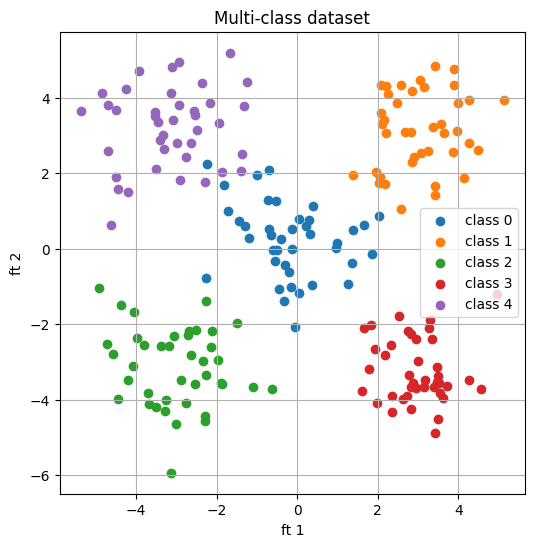

In [28]:
plot_data(x, y)

##### Testing data

In [122]:
# new datasets for testing
xte, yte = make_data(100, 5)

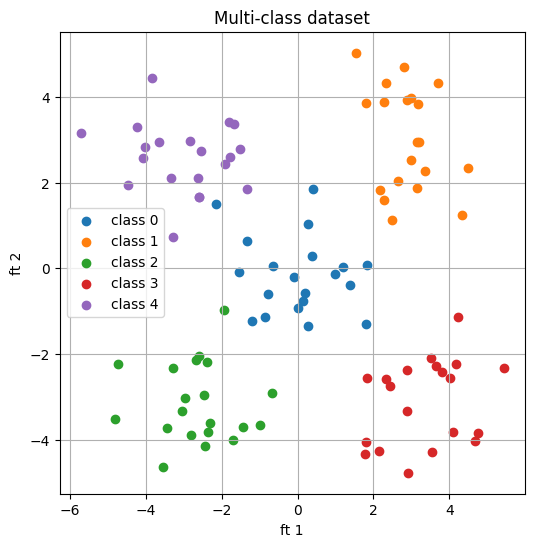

In [123]:
# visualise test data
plot_data(xte, yte)

## OvA implemntation with logitstic regression (Approach 1)

#### Model

In [136]:
def sigOvA(z):
    z = np.clip(z, -500, 500)
    return 1/(1+np.exp(-z))

In [142]:
def forwardOvA(x, w, b):
    # x:(n,ncls) | w,b:(ncls,)
    z = x @ w + b # (n,)
    p = sigOvA(z)
    return z, p

#### Loss

The binary cross-entropy formula:
$$
\mathcal{L}(w,b) = - \ell(w,b) 
                  = - \sum_{i=1}^{N} \Big[ y_i \log \sigma(z_i) + (1 - y_i) \log (1 - \sigma(z_i)) \Big]
$$
- if $z_i$ is very large positive, $\sigma(z_i)\approx1$, then $\log(1-\sigma(z_i))\approx\log(0)\rightarrow$ numerical underflow.
- if $z_i$ is very large positive, $\sigma(z_i)\approx0$, then $\log(\sigma(z_i))\approx\log(0)\rightarrow$ numerical underflow.

**Fix: compute loss using logits directly (stable cross-entropy)**
$$\mathcal{L}(w,b)=\sum_{i=1}^N\Big[\max(z_i, 0)-z_iy_i+\log(1+e^{-|z_i|})\Big]$$

In [138]:
# stable binary cross-entropy loss
## mean{ sum { y.log p + (1-y)log(1-p) } }
def cross_entropyOvA(y, logits):
    # numerically stable bin-cross-ent.
    return np.mean(np.maximum(logits, 0)
                   - logits*y
                   + np.log1p(np.exp(-np.abs(logits)))) # log1p=log(1+x)

#### Gradients

We need:
$$\frac{\partial\mathcal{L}}{\partial w},\frac{\partial\mathcal{L}}{\partial b}=\frac{\partial\mathcal{L}}{\partial z}.\frac{\partial\mathcal{z}}{\partial w,b}$$

derivation:

$$\mathcal{L}_i=\max(z_i,0)-z_i y_i+\log(1+e^{-|z_i|})$$
$$\sigma(z)=\frac{1}{1+e^{-z}}$$
$$\quad \mathcal{L}=\frac{1}{N}\sum_{i=1}^N \mathcal{L}_i\Rightarrow \frac{\partial \mathcal{L}}{\partial z_i}=\frac{1}{N}(\sigma(z_i)-y_i)$$
$$\quad \nabla_w=\frac{1}{N}X^T(\sigma(z)-y)$$
$$\nabla_b=\frac{1}{N}\sum_{i=1}^N(\sigma(z_i)-y_i)$$

In [139]:
def gradOvA(x, y, p):
    # x: (N,nin), y: (N,), preds: (N,) 
    dw = (1/x.shape[0])*(x.T @ (p-y)) # (nin,)
    db = np.mean(p-y) # scalar
    return dw, db

#### Training

In [182]:
def trainOvA(x, y, steps=300, lr=0.1):
    # x: (N. nin) | y: (nin)
    # theta: list of 2 dict. - theta[0]: weights, theta[1]: biases of k classes
    loss = [] # loss history
    for s in range(steps):
        K = len(theta[0]) # n classes
        steploss = 0
        
        for k in range(K):
            yk = (y==k).astype(np.float32) # 1 if y==k, else 0
            # forward pass
            logits, p = forwardOvA(x, theta[0][k], theta[1][k])
            # loss
            steploss += cross_entropyOvA(yk, logits)
            # backward
            dw, db = gradOvA(x, yk, p)
            # gradient descent
            theta[0][k] -= lr*dw
            theta[1][k] -= lr*db
        # average loss over K
        steploss /= K
        loss.append(steploss)

        if s%50==0:
            print(f"step: {s:4d} | avg loss: {steploss:.4f}")
    return theta, loss

In [183]:
## Instantiation
theta = [{}, {}]
theta[0] = {k:np.random.randn(x.shape[1])*0.1 for k in range(K)} # weights
theta[1] = {k:0.0 for k in range(K)}                             # biases

## Training the model
thetaOvA, lossOvA = trainOvA(x, y, steps=500, lr=0.1)

step:    0 | avg loss: 0.7286
step:   50 | avg loss: 0.2978
step:  100 | avg loss: 0.2350
step:  150 | avg loss: 0.2066
step:  200 | avg loss: 0.1901
step:  250 | avg loss: 0.1791
step:  300 | avg loss: 0.1713
step:  350 | avg loss: 0.1654
step:  400 | avg loss: 0.1607
step:  450 | avg loss: 0.1570


#### Analysis

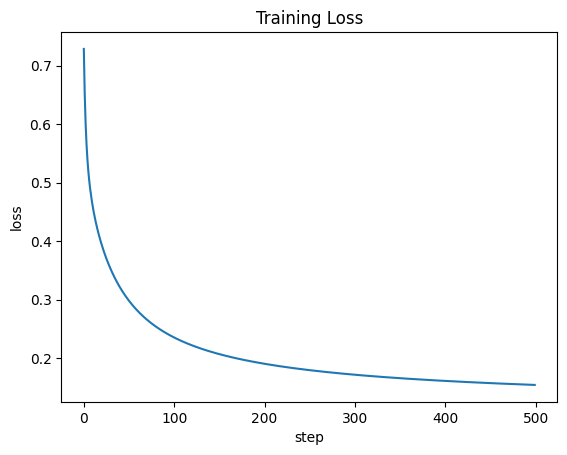

In [187]:
plt.plot(lossOvA)
plt.title("Training Loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

In [149]:
# final loss
lossOvA[-1]

0.07859815362445095

In [150]:
# weights | class: weight1, weight2
thetaOvA[0]

{0: array([-0.01650182,  0.02628176]),
 1: array([1.13114893, 1.00333342]),
 2: array([-1.04110552, -1.09533108]),
 3: array([ 1.10553928, -1.03229535]),
 4: array([-0.9714804 ,  0.99330413])}

In [151]:
# biases | class: bias
thetaOvA[1]

{0: -1.3904948823831973,
 1: -3.323049995128934,
 2: -3.415820202917245,
 3: -3.396080862985005,
 4: -3.4240182070801226}

In [208]:
def predictOvA(x, theta):
    K = len(theta[0])
    # probs: (N, K)
    probs = np.stack([forwardOvA(x, theta[0][k], theta[1][k])[1] for k in range(K)], axis=1) # stack probs
    return np.argmax(probs, axis=1)

In [209]:
# get predictions for the testing dataset
psOvA = predictOvA(xte, theta)

# calculate accuracy
accOvA = (psOvA==yte).mean()
print("Accuracy (test data): ", accOvA)

Accuracy (test data):  0.94


## Multinomial Logistic Regression Implementation (Approach 2)

#### Model

In [156]:
def softmaxMulti(z): # z: (N,K)
    z = z - np.max(z, axis=1, keepdims=True) # for numerical stability
    return np.exp(z)/np.sum(np.exp(z), axis=1, keepdims=True)

In [231]:
def forwardMulti(x, w, b): #x: (N, nin), w: (nin, K), b: (1, K)
    z = x @ w + b # z, p: (N, K)
    return softmaxMulti(z)

#### Loss

##### Probability form from logit form
$$
L(\theta) = - \theta_y^\top x + \log \sum_{j=1}^{K} e^{\theta_j^\top x}
$$
$$
L(\theta) = - \theta_y^\top x + \log \sum_{j=1}^{K} e^{\theta_j^\top x} 
= - \theta_y^\top x + \log \sum_{j=1}^{K} e^{\theta_j^\top x} - \log e^{\theta_y^\top x} + \log e^{\theta_y^\top x}
$$
Since $
\log \sum_{j=1}^{K} e^{\theta_j^\top x} 
= \log \frac{\sum_{j=1}^{K} e^{\theta_j^\top x}}{e^{\theta_y^\top x}} + \log e^{\theta_y^\top x}
$ because, $\log(a)=\log(a/b)+\log(b)$,

$$
L(\theta) = - \theta_y^\top x + \log \left( \frac{\sum_{j=1}^{K} e^{\theta_j^\top x}}{e^{\theta_y^\top x}} \right) + \theta_y^\top x
$$

$$
L(\theta) = - \log \frac{e^{\theta_y^\top x}}{\sum_{j=1}^{K} e^{\theta_j^\top x}}
$$

$$
p_k = \frac{e^{\theta_k^\top x}}{\sum_{j=1}^{K} e^{\theta_j^\top x}} 
\quad\implies\quad
L(\theta) = - \log p_y
$$

$$
L(\theta) = - \sum_{k=1}^{K} \mathbf{1}(y=k) \log p_k
$$

In [172]:
def cross_entropyMulti(y, pred): # y: (N,) pred: (N, K)
    loss = -np.log(pred[np.arange(len(y)), y] +1e-15) # select probs of true class, add epsilon to avoid log 0
    return np.mean(loss)

#### Gradients

$$\text{Start with probability form (batch size } N \text{, } K \text{ classes):}$$

$$
L = - \frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} Y_{i,k} \log P_{i,k}, \quad
P_{i,k} = \frac{e^{Z_{i,k}}}{\sum_{j=1}^{K} e^{Z_{i,j}}}, \quad Z = X W + b
$$

$$\text{Step 1: derivative w.r.t logits } Z_{i,k}:$$

$$
\frac{\partial L}{\partial Z_{i,k}} = P_{i,k} - Y_{i,k}
$$

$$\text{Reason: } \frac{\partial}{\partial z} [-y \log p(z)] = p - y \text{ for softmax probabilities.}$$

$$\text{Step 2: derivative w.r.t weights } W:$$

$$
\frac{\partial L}{\partial W} = \frac{1}{N} X^\top (P - Y)
$$

$$\text{Step 3: derivative w.r.t biases } b:$$

$$
\frac{\partial L}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} (P_i - Y_i)
$$
$$
\text{All shapes: } 
X \in \mathbb{R}^{N \times d}, W \in \mathbb{R}^{d \times K}, b \in \mathbb{R}^K,\ P,Y\text{(one-hot)} \in \mathbb{R}^{N \times K}$$

In [171]:
def gradMulti(x, y, p): # x: (N, nin), y: (N,), p: (N, K)
    # y(N,) -> (N, K): one-hot
    _y = np.zeros_like(p) # (N, K)
    _y[np.arange(x.shape[0]), y] = 1
    
    dw = (1/x.shape[0])*(x.T @ (p-_y)) # (d, K)
    db = np.mean(p-_y, axis=0) # (K,)
    return dw, db

#### Training

In [185]:
def trainMulti(x, y, K, steps=300, lr=0.1):
    # parameter setup
    w = np.random.randn(x.shape[1], K)*0.1 # (nin, K)
    b = np.zeros(K) # np will broadcast to (K,)
    loss = [] # loss history
    for s in range(steps):
        # forward pass
        p = forwardMulti(x, w, b)
        # loss
        steploss = cross_entropyMulti(y, p)
        loss.append(steploss)
        # backward
        dw, db = gradMulti(x, y, p)
        # gradient descent
        w -= lr*dw
        b -= lr*db

        if s%50==0:
            print(f"step: {s:4d} | loss: {steploss:.4f}")
    return (w, b), loss

In [196]:
thetaMulti, lossMulti = trainMulti(x, y, K)

step:    0 | loss: 1.7690
step:   50 | loss: 0.3819
step:  100 | loss: 0.2870
step:  150 | loss: 0.2323
step:  200 | loss: 0.1975
step:  250 | loss: 0.1739


#### Analysis

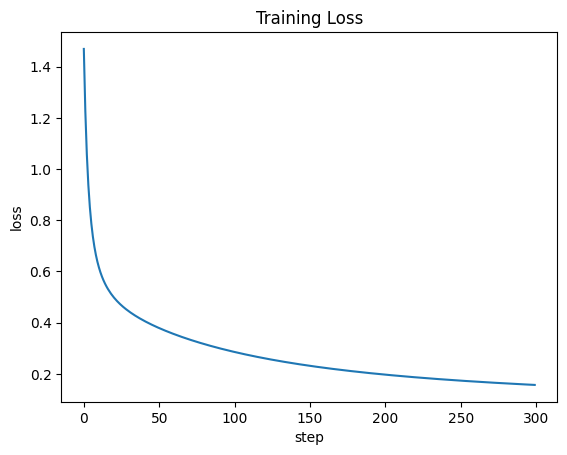

In [188]:
plt.plot(lossMulti)
plt.title("Training Loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

In [197]:
# final loss
lossMulti[-1]

0.1570942676770774

In [199]:
# weights
thetaMulti[0]

array([[-0.07259454,  1.09893771, -1.01230082,  1.03669736, -1.00870341],
       [ 0.02134199,  0.97950058, -1.20920354, -1.09642403,  0.97064776]])

In [201]:
# biases
thetaMulti[1]

array([ 2.16692021, -0.51830726, -0.5214295 , -0.52577225, -0.6014112 ])

In [244]:
def predictMulti(x, theta):
    preds = forwardMulti(x, theta[0], theta[1]) # (N, K)
    return np.argmax(preds, axis=1)

In [245]:
xte.shape

(100, 2)

In [246]:
thetaMulti[0][:,1].shape

(2,)

In [247]:
# get predictions for testing dataset (same as OvA)
psMulti = predictMulti(xte, thetaMulti)

In [248]:
psMulti.shape

(100,)

In [249]:
# calculate accuracy
accMulti = (psMulti==yte).mean()
print("Accuracy (test data): ", accMulti)

Accuracy (test data):  0.98
